In [2]:
!git clone https://github.com/Nouman14-ai/CV_A2_LowVis_Nouman_22F-3788.git

Cloning into 'CV_A2_LowVis_Nouman_22F-3788'...
remote: Enumerating objects: 627, done.
remote: Counting objects: 100% (627/627), done.
remote: Compressing objects: 100% (418/418), done.
remote: Total 627 (delta 202), reused 605 (delta 197), pack-reused 0 (from 0)
Receiving objects: 100% (627/627), 28.19 MiB | 38.13 MiB/s, done.
Resolving deltas: 100% (202/202), done.


In [3]:
import os

dataset_path = "/content/CV_A2_LowVis_Nouman_22F-3788/dataset/Rain"

files = os.listdir(dataset_path)

print("Total images:", len(files))
print("First 5 files:", files[:5])

Total images: 202
First 5 files: ['rain_storm-134.jpg', 'rain_storm-407.jpg', 'rain_storm-289.jpg', 'rain_storm-013.jpg', 'rain_storm-225.jpg']


In [4]:
!pip install ultralytics
!pip install opencv-python
!pip install matplotlib
!pip install numpy
!pip install pandas
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.6 MB/s eta 0:00:00


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [6]:
images = []

for file in os.listdir(dataset_path):

    if file.endswith(('.jpg', '.png', '.jpeg')):

        img_path = os.path.join(dataset_path, file)

        img = cv2.imread(img_path)

        if img is not None:
            images.append(img)

print("Images loaded:", len(images))

Images loaded: 200


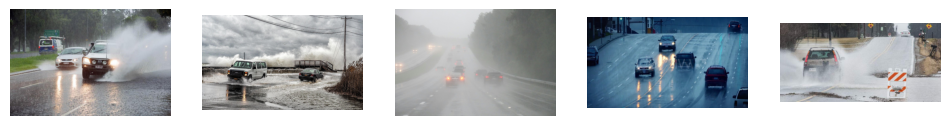

In [7]:
plt.figure(figsize=(12,6))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))

    plt.axis("off")

plt.show()

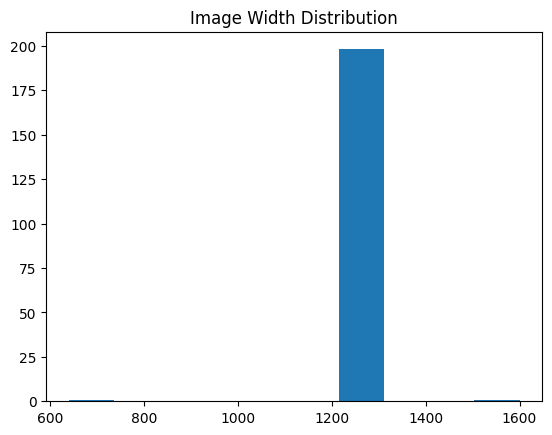

In [8]:
widths = []
heights = []

for img in images:

    h, w, _ = img.shape

    widths.append(w)
    heights.append(h)

plt.hist(widths)

plt.title("Image Width Distribution")

plt.show()

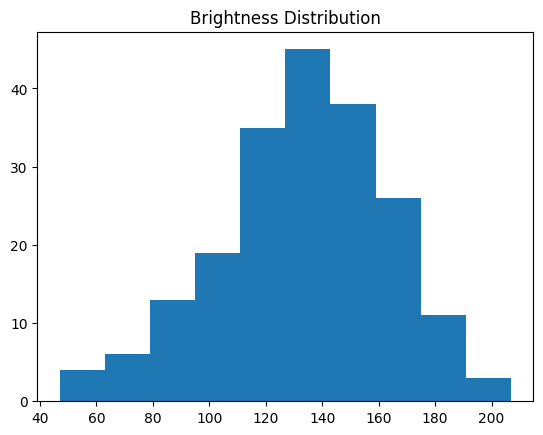

In [9]:
brightness = []

for img in images:

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness.append(np.mean(gray))

plt.hist(brightness)

plt.title("Brightness Distribution")

plt.show()

In [10]:
def histogram_equalization(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    eq = cv2.equalizeHist(gray)

    return eq

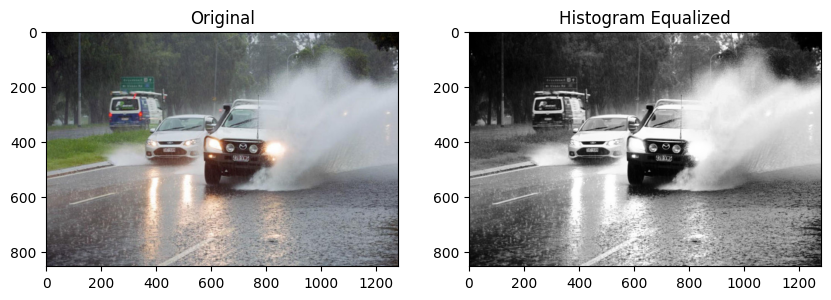

In [11]:
img = images[0]

result = histogram_equalization(img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title("Histogram Equalized")
plt.imshow(result, cmap='gray')

plt.show()

In [12]:
def apply_clahe(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    return clahe.apply(gray)

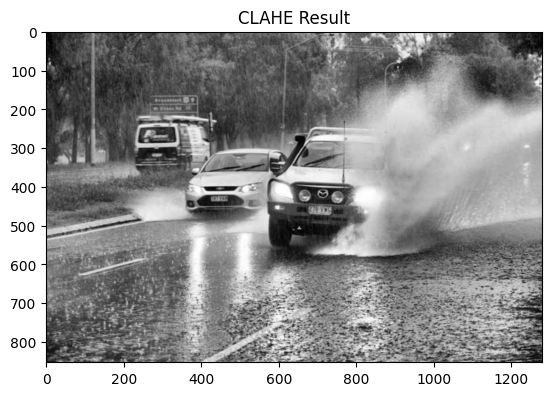

In [13]:
clahe_result = apply_clahe(images[0])

plt.imshow(clahe_result, cmap='gray')
plt.title("CLAHE Result")
plt.show()

In [14]:
def gamma_correction(image, gamma=1.5):

    invGamma = 1.0 / gamma

    table = np.array([
        ((i / 255.0) ** invGamma) * 255
        for i in range(256)
    ]).astype("uint8")

    return cv2.LUT(image, table)

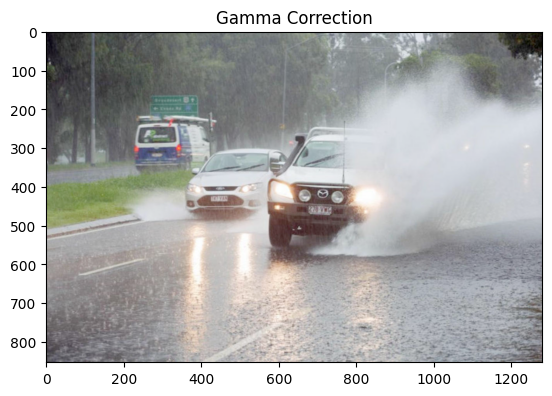

In [15]:
gamma_img = gamma_correction(images[0], 1.5)

plt.imshow(cv2.cvtColor(gamma_img, cv2.COLOR_BGR2RGB))
plt.title("Gamma Correction")
plt.show()

In [16]:
!pip install ultralytics

In [17]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [18]:
results = model.predict(
    source=dataset_path,
    conf=0.25,
    save=True
)


image 1/200 /content/CV_A2_LowVis_Nouman_22F-3788/dataset/Rain/rain_storm-001.jpg: 448x640 2 persons, 3 cars, 1 umbrella, 359.6ms
image 2/200 /content/CV_A2_LowVis_Nouman_22F-3788/dataset/Rain/rain_storm-002.jpg: 416x640 3 persons, 1 car, 1 motorcycle, 163.1ms
image 3/200 /content/CV_A2_LowVis_Nouman_22F-3788/dataset/Rain/rain_storm-003.jpg: 352x640 1 boat, 143.2ms
image 4/200 /content/CV_A2_LowVis_Nouman_22F-3788/dataset/Rain/rain_storm-004.jpg: 448x640 1 person, 1 car, 1 traffic light, 2 umbrellas, 1 potted plant, 156.2ms
image 5/200 /content/CV_A2_LowVis_Nouman_22F-3788/dataset/Rain/rain_storm-005.jpg: 448x640 1 person, 1 car, 1 surfboard, 179.7ms
image 6/200 /content/CV_A2_LowVis_Nouman_22F-3788/dataset/Rain/rain_storm-006.jpg: 448x640 1 person, 5 cars, 1 umbrella, 155.0ms
image 7/200 /content/CV_A2_LowVis_Nouman_22F-3788/dataset/Rain/rain_storm-007.jpg: 448x640 1 car, 1 boat, 154.0ms
image 8/200 /content/CV_A2_LowVis_Nouman_22F-3788/dataset/Rain/rain_storm-008.jpg: 448x640 11 car

In [20]:
print("Total images processed:", len(results))

Total images processed: 200


In [21]:
vehicle_count = 0

for r in results:
    vehicle_count += len(r.boxes)

print("Total detected vehicles:", vehicle_count)

Total detected vehicles: 1098


In [22]:
for i, r in enumerate(results[:5]):
    print(f"Image {i+1}: {len(r.boxes)} detections")


Image 1: 6 detections
Image 2: 5 detections
Image 3: 1 detections
Image 4: 6 detections
Image 5: 3 detections


In [23]:
import shutil

source = "/content/runs/detect"
destination = "/content/CV_A2_LowVis_Nouman_22F-3788/results"

shutil.copytree(source, destination, dirs_exist_ok=True)

print("Results saved to GitHub folder structure")

Results saved to GitHub folder structure


In [24]:
enhanced = gamma_correction(images[0], 1.5)

enhanced_results = model.predict(enhanced)


0: 448x640 3 cars, 1 truck, 160.2ms
Speed: 4.3ms preprocess, 160.2ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


In [25]:
print("Enhanced detections:", len(enhanced_results[0].boxes))

Enhanced detections: 4
